# Trabalho 1 — Aplicações de Regressão e Classificação
**Disciplina:** Aprendizado de Máquina em Sistemas Dinâmicos — Prof. Americo Cunha
**Aluno:** João Pedro Dias de Carvalho — CompMat/UERJ

**Dataset:** *Rain in Australia* (Kaggle, `jsphyg/weather-dataset-rattle-package`) — observações
meteorológicas diárias de 49 estações do *Bureau of Meteorology* da Austrália (2007–2017).

| Tarefa | Alvo | Modelos |
|---|---|---|
| **Regressão** (série temporal) | Temperatura máxima média **semanal** em Sydney (°C) | SARIMAX, Prophet, Decomposição STL + ARIMA e **Combinado** (média simples dos três) |
| **Classificação** (binária) | `RainTomorrow`: vai chover amanhã? (> 1 mm) | Regressão Logística (GLM), KNN, Random Forest, LightGBM |

Este notebook executa o projeto **etapa por etapa**. Toda a lógica está no pacote `src/`
(o mesmo usado pelo `main.py`), então os números aqui são idênticos aos do relatório.
Cada etapa traz a explicação do *porquê* da decisão tomada.

> Tempo total de execução: ~25 min em 2 núcleos (a maior parte é o ajuste do Random Forest).

## 0. Configuração do ambiente

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config as cfg
from src import data, eda
from src import regression as reg
from src import classification as clf
from src import plot_style

plot_style.set_style()
plot_style.SHOW = True          # exibe as figuras no notebook (além de salvar em outputs/figures)
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("Semente aleatória:", cfg.SEED)

Semente aleatória: 42


---
# 1. Aquisição e contextualização dos dados

O conjunto vem do Kaggle e reúne cerca de 10 anos de observações diárias do serviço meteorológico
australiano (BoM). Cada linha é um par **(estação, dia)** com medições de temperatura, chuva,
evaporação, insolação, vento, umidade, pressão e nebulosidade às 9h e às 15h.

Por que este dataset é adequado?
* é **real e grande** (≈145 mil linhas, 23 colunas) e tem **problemas reais** de qualidade (≈10% das células faltando,
  ausência estrutural por estação, variáveis muito assimétricas);
* tem uma **dimensão temporal** clara → permite modelar uma série temporal (o tema da disciplina, sistemas dinâmicos);
* tem um alvo binário **natural e desbalanceado** (`RainTomorrow`, ~22% de "Sim").

O download usa o endpoint público da API do Kaggle (`src/data.py`). Se o arquivo já existir em `data/`, ele é reaproveitado.

In [2]:
data.download_dataset()
df = data.load_raw()
print(f"{df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head()

[data] Arquivo já existe: weatherAUS.csv
145,460 linhas x 23 colunas


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-07-01,Adelaide,8.800,15.700,5.000,1.600,2.600,NW,48.000,SW,W,13.000,15.000,92.000,67.000,"1,017.400","1,017.700",NaN,NaN,13.500,14.900,Yes,No
1,2008-07-02,Adelaide,12.700,15.800,0.800,1.400,7.800,SW,35.000,SSW,SW,13.000,15.000,75.000,52.000,"1,022.400","1,022.600",NaN,NaN,13.700,15.500,No,No
2,2008-07-03,Adelaide,6.200,15.100,0.000,1.800,2.100,W,20.000,NNE,SW,2.000,11.000,81.000,56.000,"1,027.800","1,026.500",NaN,NaN,9.300,13.900,No,No
3,2008-07-04,Adelaide,5.300,15.900,0.000,1.400,8.000,NNE,30.000,NNE,NE,6.000,13.000,71.000,46.000,"1,028.700","1,025.600",NaN,NaN,10.200,15.300,No,No
4,2008-07-05,Adelaide,9.800,15.400,0.000,NaN,0.900,N,30.000,NNE,NE,9.000,9.000,56.000,67.000,"1,023.600","1,020.200",NaN,NaN,11.300,13.800,No,NaN


In [3]:
# Dicionário de variáveis
pd.Series(data.VARIABLES, name="Descrição").to_frame()

,Descrição
Date,Data da observação
Location,Estação meteorológica (49 locais)
MinTemp,Temperatura mínima (°C)
MaxTemp,Temperatura máxima (°C)
Rainfall,Precipitação nas 24h até 9h (mm)
Evaporation,Evaporação 'Class A pan' nas 24h até 9h (mm)
Sunshine,Horas de sol no dia
WindGustDir,Direção da rajada mais forte (16 pontos)
WindGustSpeed,Velocidade da rajada mais forte (km/h)
WindDir9am,Direção do vento às 9h


In [4]:
eda.overview(df)

{'n_linhas': 145460,
 'n_colunas': 23,
 'n_estacoes': 49,
 'data_inicio': Timestamp('2007-11-01 00:00:00'),
 'data_fim': Timestamp('2017-06-25 00:00:00'),
 'n_numericas': 16,
 'n_categoricas': 6,
 'pct_celulas_faltantes': np.float64(10.259745694319072),
 'pct_linhas_completas': 38.78729547641964}

---
# 2. Análise Exploratória (EDA) e pré-processamento

## 2.1 Estatísticas descritivas
Olhamos média, desvio-padrão, extremos, **assimetria** e **% de ausentes** de cada variável numérica.

In [5]:
eda.descriptive_table(df)

,Média,DP,Mín,Mediana,Máx,Assimetria,Faltantes (%)
MinTemp,12.194,6.398,-8.500,12.000,33.900,0.021,1.021
MaxTemp,23.221,7.119,-4.800,22.600,48.100,0.221,0.867
Rainfall,2.361,8.478,0.000,0.000,371.000,9.836,2.242
Evaporation,5.468,4.194,0.000,4.800,145.000,3.761,43.167
Sunshine,7.611,3.785,0.000,8.400,14.500,-0.496,48.010
WindGustSpeed,40.035,13.607,6.000,39.000,135.000,0.875,7.056
WindSpeed9am,14.043,8.915,0.000,13.000,130.000,0.778,1.215
WindSpeed3pm,18.663,8.810,0.000,19.000,87.000,0.628,2.105
Humidity9am,68.881,19.029,0.000,70.000,100.000,-0.484,1.825
Humidity3pm,51.539,20.796,0.000,52.000,100.000,0.034,3.098


**Leitura:** `Rainfall` (assimetria ≈ 9,8) e `Evaporation` (≈ 3,8) são fortemente assimétricas à direita —
a maioria dos dias tem chuva zero e alguns poucos têm dezenas ou centenas de mm. Isso motiva a transformação
$\log(1+x)$ mais adiante. As demais variáveis têm distribuições razoavelmente simétricas.

## 2.2 Dados ausentes
É importante saber **como** os dados faltam, não só quanto. Se a ausência for aleatória (MCAR), imputar pela
mediana é inofensivo; se for **estrutural** (a estação não tem o instrumento), a própria ausência carrega informação.

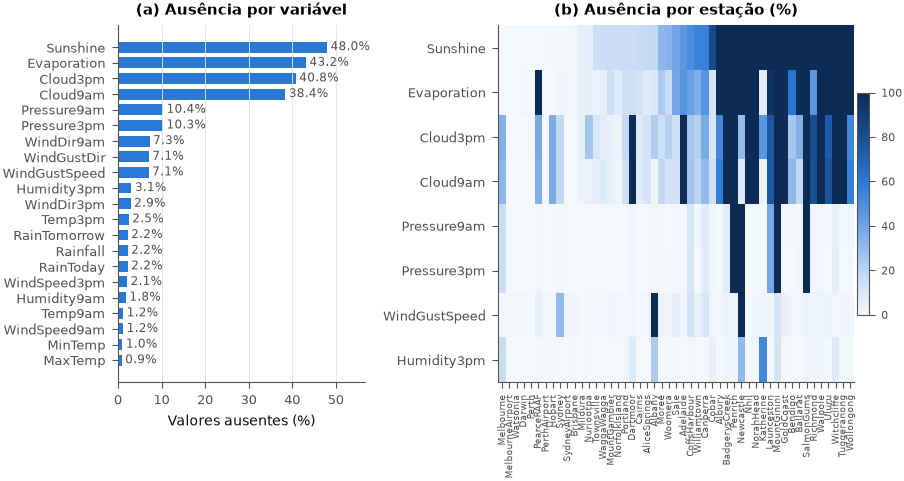

,Faltantes (%),Estações sem medição
Sunshine,48.010,19
Evaporation,43.167,16
Cloud3pm,40.807,12
Cloud9am,38.422,12
Pressure9am,10.357,4
Pressure3pm,10.331,4
WindGustSpeed,7.056,2
Humidity3pm,3.098,0
Temp3pm,2.481,0
Rainfall,2.242,0


In [6]:
miss = eda.missing_analysis(df)
miss

**Leitura:** `Sunshine`, `Evaporation`, `Cloud9am/3pm` têm 38–48% de ausência, e o mapa (b) mostra que ela é
**estrutural**: 19 estações nunca mediram `Sunshine` e 16 nunca mediram `Evaporation`. Decisões tomadas:

1. **Não descartar linhas** com ausentes (só 39% das linhas estão completas — perderíamos 61% dos dados).
2. Imputar pela **mediana** *dentro* do pipeline de validação cruzada (sem vazamento).
3. Criar **indicadores de ausência** (`miss_Sunshine`, ...) para que o modelo possa aprender com o padrão de ausência.
4. Remover apenas as linhas sem o **alvo** `RainTomorrow` (2,2%) — não há como treinar/avaliar sem rótulo.

## 2.3 Inconsistências
Regras físicas/lógicas que os dados devem obedecer.

In [7]:
eda.consistency_checks(df)

,Ocorrências
"Linhas duplicadas (Date, Location)",0
MinTemp > MaxTemp,0
"Umidade fora de [0, 100]",0
Precipitação negativa,0
Nebulosidade > 8 oitavos,3
RainToday incoerente com Rainfall > 1 mm,0
RainTomorrow(t) diferente de RainToday(t+1),0
Datas faltantes no calendário (estação-dia),4112


**Leitura:** a base é bem consistente. Três registros de nebulosidade = 9 (código de "céu obstruído", não uma
medida em oitavos) viram `NaN`. Duas checagens de coerência interna passam integralmente:
`RainToday = Sim ⇔ Rainfall > 1 mm` e `RainTomorrow(t) = RainToday(t+1)`. A segunda confirma a definição do alvo
**e** alerta para vazamento: nunca podemos usar informação do dia $t+1$ como entrada. Há 4.112 dias faltando no
calendário de algumas estações (lacunas de coleta), tratados na construção da série e das variáveis defasadas.

In [8]:
dfc = eda.clean(df)   # aplica as correções (Cloud = 9 -> NaN)

## 2.4 Distribuições

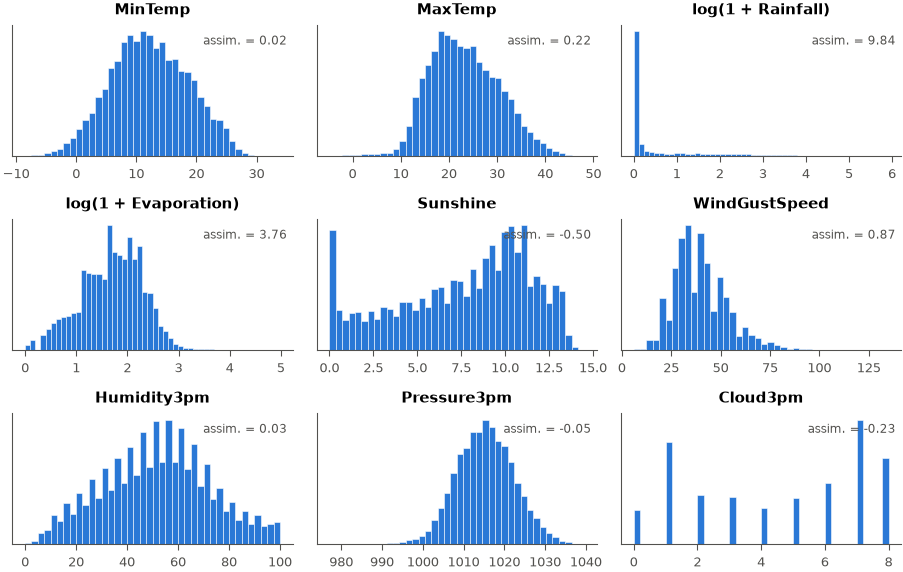

In [9]:
eda.distributions(dfc)

**Leitura:** temperatura, umidade e pressão são aproximadamente unimodais e simétricas. Mesmo após
$\log(1+x)$, `Rainfall` mantém um pico em zero (dias secos) — é uma distribuição mista (massa em zero + cauda contínua).

## 2.5 Outliers (regra de Tukey, 1,5 × IQR)

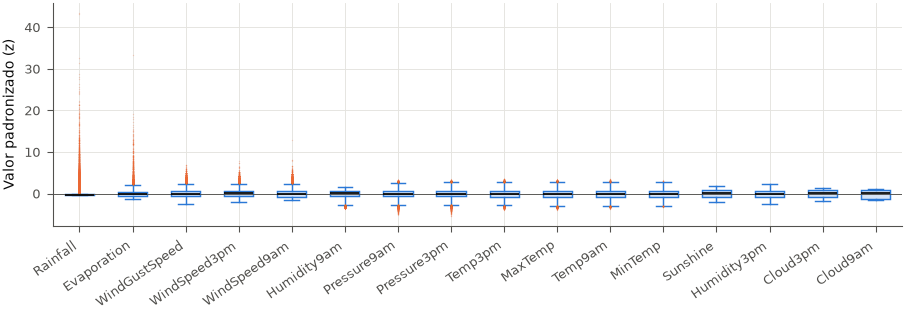

,Limite inf.,Limite sup.,Outliers,Outliers (%)
Rainfall,-1.200,2.000,25578,17.987
Evaporation,-4.600,14.600,1995,2.413
WindGustSpeed,5.500,73.500,3092,2.287
WindSpeed3pm,-3.500,40.500,2523,1.772
WindSpeed9am,-11.000,37.000,1817,1.265
Humidity9am,18.000,122.000,1425,0.998
Pressure9am,998.650,"1,036.650",1191,0.913
Pressure3pm,996.000,"1,034.400",919,0.705
Temp3pm,1.900,41.100,764,0.539
MaxTemp,2.450,43.650,489,0.339


In [10]:
eda.outlier_table(dfc)

**Decisão:** os outliers de `Rainfall` (≈18% dos dias pela regra de Tukey!), `Evaporation` e velocidade do vento são
**eventos meteorológicos reais** (tempestades, dias muito quentes e secos), justamente os que interessam para prever
chuva. Por isso **não foram removidos**; em vez disso: (i) $\log(1+x)$ comprime a cauda; (ii) usamos modelos de árvore,
que são invariantes a transformações monótonas e robustos a valores extremos; (iii) padronização (z-score) para os
modelos sensíveis à escala (logística e KNN).

## 2.6 Correlações

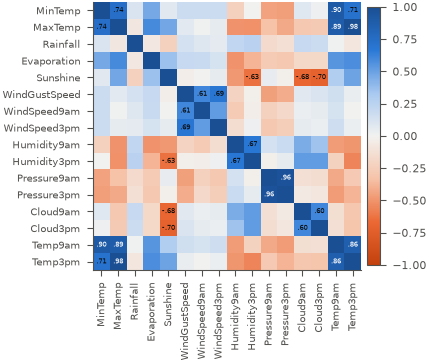

correlação de Pearson
MaxTemp       Temp3pm                       0.985
Pressure9am   Pressure3pm                   0.961
MinTemp       Temp9am                       0.902
MaxTemp       Temp9am                       0.887
Temp9am       Temp3pm                       0.861
MinTemp       MaxTemp                       0.737
              Temp3pm                       0.709
Sunshine      Cloud3pm                     -0.704
WindGustSpeed WindSpeed3pm                  0.686
Sunshine      Cloud9am                     -0.675

In [11]:
corr = eda.correlation(dfc)
pares = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
             .sort_values(key=np.abs, ascending=False))
pares.head(10).to_frame("correlação de Pearson")

**Leitura:** há blocos muito colineares (`Pressure9am`–`Pressure3pm` ≈ 0,96; `MaxTemp`–`Temp3pm` ≈ 0,98).
Para a regressão logística isso infla a variância dos coeficientes (usamos regularização L2); para árvores é
inofensivo. Por isso, em vez de manter só os níveis, criamos **diferenças** (ex.: `Pressure3pm − Pressure9am`),
que são pouco correlacionadas com os níveis e carregam a **dinâmica** do dia.

## 2.7 Alvo da classificação

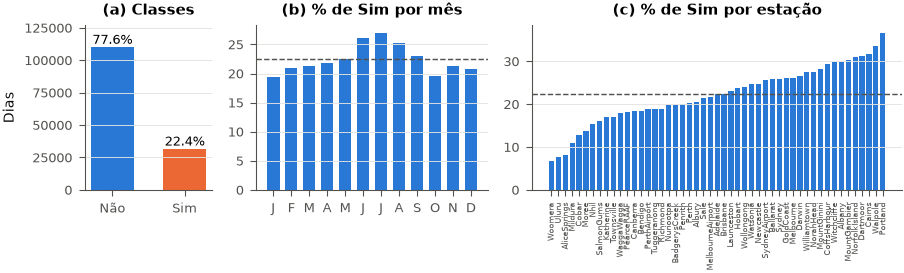

,Proporção de Sim (%),Razão Não:Sim
0,22.418,3.461


In [12]:
eda.target_analysis(dfc)

**Leitura:** 22,4% de "Sim" → razão ≈ 3,5 : 1. Com esse desbalanceamento a **acurácia é enganosa** (um modelo que
sempre diz "Não" acerta 77,6%). Por isso usaremos ROC-AUC, PR-AUC, F1, precisão e revocação, pesos de classe e
ajuste de limiar. A taxa varia muito por estação (7% em Woomera, no deserto, a 37% em Portland) e por mês
(pico no inverno austral) → `Location` e o dia do ano são variáveis relevantes.

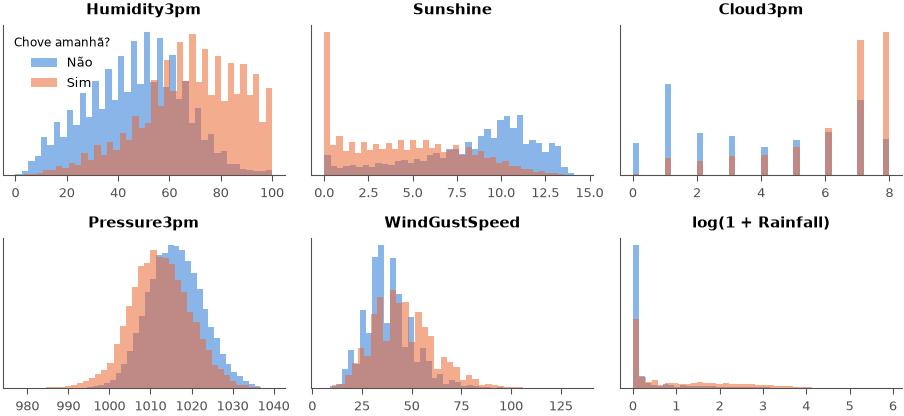

In [13]:
eda.features_vs_target(dfc)

**Leitura:** a umidade às 15h e a nebulosidade separam bem as classes; dias de chuva amanhã têm menos sol e
pressão mais baixa. Já se antecipa que `Humidity3pm` será uma das variáveis mais importantes.

---
# 3. Regressão — previsão da temperatura máxima semanal em Sydney

### Definição do problema
* **Alvo (contínuo):** $y_t$ = média semanal da temperatura máxima diária em Sydney (°C).
* **Por que semanal?** A série diária é dominada por ruído sinótico (frentes frias de 2–3 dias), praticamente
  imprevisível com semanas de antecedência. A agregação semanal filtra esse ruído e realça a dinâmica sazonal
  e de baixa frequência, que é o que modelos de séries temporais capturam bem. Período sazonal: $P = 365{,}25/7 \approx 52{,}18$ semanas.
* **Por que é supervisionado?** Cada modelo aprende uma função $f$ do passado para o futuro, $\hat y_{t+h} = f(y_{1:t}, t)$,
  a partir de pares (passado, futuro) observados.

### Protocolo (sem olhar o futuro)
| Conjunto | Período | Uso |
|---|---|---|
| Treino | 2008-02 → 2014-12 | ajustar modelos na busca de hiperparâmetros |
| Validação | 2015 | escolher hiperparâmetros (RMSE) |
| Teste | 2016-01 → 2017-06 (78 semanas) | avaliação final, modelos re-treinados em treino+validação |

Dois cenários de teste: **(A) longo prazo** — uma única previsão de $h = 1,\dots,78$ semanas a partir do fim de 2015;
**(B) um passo à frente** — toda semana prevemos a próxima com tudo o que já foi observado.
Mais um **backtest com origem móvel** (4 anos, $h = 52$) para medir a estabilidade.

## 3.1 Construção da série

{'dias_faltantes': 91, 'semanas_interpoladas': 12, 'n_semanas': 490, 'inicio': Timestamp('2008-02-10 00:00:00'), 'fim': Timestamp('2017-06-25 00:00:00')}
treino = 360 semanas | validação = 52 | teste = 78


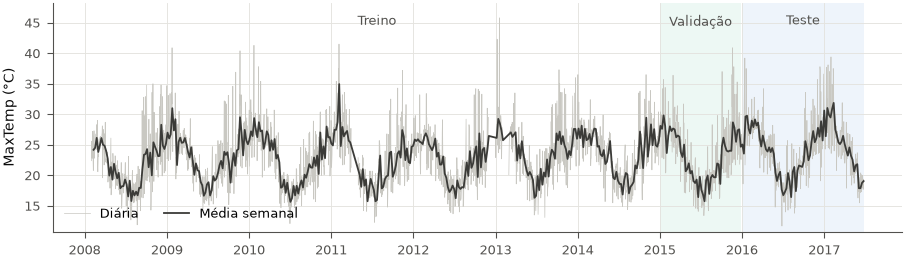

In [14]:
daily, y, info = reg.build_series(df)
train, val, test = reg.split_series(y)
train_full = pd.concat([train, val])
print(info)
print(f"treino = {len(train)} semanas | validação = {len(val)} | teste = {len(test)}")
reg.plot_series(daily, y)

Sydney tem 91 dias sem `MaxTemp`. A média semanal exige ≥ 4 dias válidos; as 12 semanas que não atingem isso
são **interpoladas linearmente no tempo** (lacunas isoladas e curtas, < 2,5% da série). A série semanal mostra
um ciclo anual muito regular, de ≈ 19 °C no inverno a ≈ 27 °C no verão.

## 3.2 Estacionariedade e decomposição

,ADF estat.,ADF p-valor,KPSS estat.,KPSS p-valor
Série original,-7.451,0.000,0.074,0.100
Dessazonalizada (STL),-11.132,0.000,1.026,0.010


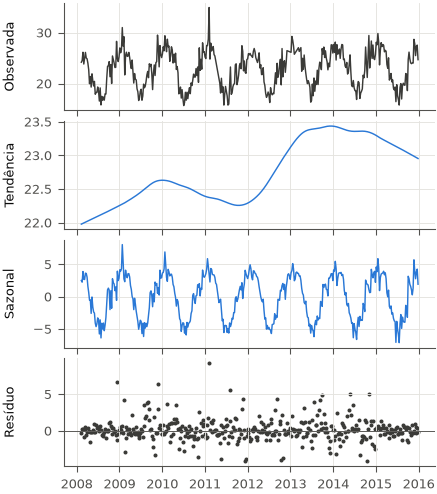

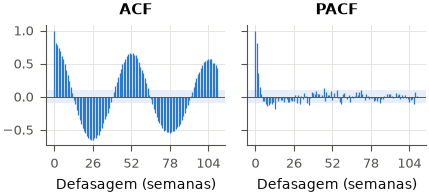

{'forca_sazonal': np.float64(0.8107390364603854),
 'forca_tendencia': np.float64(0.09129053868952897)}

In [15]:
display(reg.stationarity_tests(train_full))
forca = reg.plot_decomposition(train_full)
forca

**Leitura:**
* **ADF** ($H_0$: raiz unitária) é rejeitado nas duas versões → não há tendência estocástica; **não é preciso diferenciar** ($d = 0$).
* **KPSS** ($H_0$: estacionariedade) *não* rejeita na série original, mas **rejeita na série dessazonalizada** (p ≤ 0,01):
  sobra uma variação lenta de nível (anos mais quentes/frios, aquecimento). Isso justifica testar um termo de
  **tendência determinística** (`trend='ct'`) nos modelos.
* A **força da sazonalidade** $F_S = \max(0, 1 - \mathrm{Var}(R)/\mathrm{Var}(S+R)) \approx 0{,}81$ é alta e a da tendência é baixa (≈ 0,09).
* A ACF oscila com período de 52 semanas (sazonalidade determinística), confirmando a estrutura.

## 3.3 Modelo 1 — SARIMAX (regressão harmônica dinâmica)

Com período de 52 semanas, o SARIMA "clássico" com polinômio sazonal $(P,D,Q)_{52}$ é caro, instável e exige um
período inteiro. A alternativa recomendada por Hyndman & Athanasopoulos (FPP3) é usar o **X do SARIMAX**:
termos de Fourier como regressores exógenos e erros ARMA:

$$ y_t = \beta_0 + \beta_1 t + \sum_{k=1}^{K}\Big[a_k \sin\tfrac{2\pi k t}{P} + b_k\cos\tfrac{2\pi k t}{P}\Big] + \eta_t,
\qquad \phi(B)\,\eta_t = \theta(B)\,\varepsilon_t,\ \ \varepsilon_t \sim \mathcal N(0,\sigma^2). $$

Os parâmetros são estimados por **máxima verossimilhança** via filtro de Kalman. Busca em grade:
$K \in \{1,2,3,4,6\}$, $p, q \in \{0,1,2\}$, tendência ∈ {constante, constante + linear}, escolha pelo **AIC**
$= -2\log L + 2k$ (verossimilhança dos erros 1 passo à frente penalizada pela complexidade).

In [16]:
best_sx, tab_sx = reg.tune_sarimax(train, val)
tab_sx.head(10)

[SARIMAX] melhor (AIC): {'order': (1, 0, 1), 'K': 2, 'trend': 'ct'}  AIC = 1400.9  RMSE val = 1.635


,K,p,q,tendência,AIC,RMSE val
0,2,1,1,ct,"1,400.872",1.635
1,2,2,1,ct,"1,400.874",1.641
2,2,0,2,ct,"1,400.891",1.632
3,2,1,2,ct,"1,400.984",1.639
4,3,1,1,ct,"1,402.224",1.660
5,3,0,2,ct,"1,402.414",1.655
6,2,2,2,ct,"1,402.589",1.644
7,3,2,1,ct,"1,402.780",1.675
8,3,1,2,ct,"1,402.970",1.672
9,2,2,0,ct,"1,403.652",1.670


O AIC escolhe **ARMA(1,1) + K = 2 harmônicos + tendência linear**. Note que a configuração com menor RMSE de
validação seria ARMA(0,0) (só Fourier), mas seus resíduos são autocorrelacionados (viola a premissa $\varepsilon_t$ i.i.d.).
O AIC prefere o modelo que **explica a dinâmica de curto prazo**, o que se paga no cenário "um passo à frente".

In [17]:
sx = reg.SarimaxModel(**best_sx).fit(train_full)
print(sx.res_.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     12.7207      5.466      2.327      0.020       2.007      23.434
drift          0.0017      0.001      1.951      0.051   -7.64e-06       0.003
sin1           0.8660      0.160      5.411      0.000       0.552       1.180
cos1           4.2033      0.156     26.865      0.000       3.897       4.510
sin2           0.3340      0.145      2.303      0.021       0.050       0.618
cos2          -0.8036      0.165     -4.867      0.000      -1.127      -0.480
ar.L1          0.4292      0.245      1.753      0.080      -0.051       0.909
ma.L1         -0.2674      0.262     -1.020      0.308      -0.781       0.246
sigma2         2.7016      0.151     17.918      0.000       2.406       2.997


## 3.4 Modelo 2 — Prophet

Modelo aditivo bayesiano (Taylor & Letham, 2018), ajustado por MAP no Stan:
$$ y(t) = g(t) + s(t) + \varepsilon_t,\qquad g(t) = (k + \mathbf a(t)^\top\boldsymbol\delta)\,t + (m + \mathbf a(t)^\top\boldsymbol\gamma), \qquad
s(t) = \sum_{n=1}^{N}\Big[a_n\cos\tfrac{2\pi n t}{365{,}25} + b_n \sin\tfrac{2\pi n t}{365{,}25}\Big]. $$
$g$ é uma tendência linear por partes (pontos de mudança com *prior* Laplace de escala $\tau$) e $s$ uma série de
Fourier anual (prior normal de escala $\sigma_s$). Grade: $N \in \{3,5,10\}$, $\tau \in \{0{,}001; 0{,}01; 0{,}1; 0{,}5\}$,
$\sigma_s \in \{1, 10\}$, escolha pelo RMSE na validação.

In [18]:
best_pr, tab_pr = reg.tune_prophet(train, val)
tab_pr.head(10)

Importing plotly failed. Interactive plots will not work.


21:52:01 - cmdstanpy - INFO - Chain [1] start processing


21:52:01 - cmdstanpy - INFO - Chain [1] done processing


21:52:01 - cmdstanpy - INFO - Chain [1] start processing


21:52:01 - cmdstanpy - INFO - Chain [1] done processing


21:52:01 - cmdstanpy - INFO - Chain [1] start processing


21:52:01 - cmdstanpy - INFO - Chain [1] done processing


21:52:01 - cmdstanpy - INFO - Chain [1] start processing


21:52:01 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:02 - cmdstanpy - INFO - Chain [1] done processing


21:52:02 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


21:52:03 - cmdstanpy - INFO - Chain [1] start processing


21:52:03 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] melhor: {'fourier_order': 3, 'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0}  RMSE val = 1.538


,N Fourier,tau,sigma_s,RMSE val
0,3,0.001,10.000,1.538
1,5,0.001,1.000,1.543
2,5,0.001,10.000,1.545
3,3,0.001,1.000,1.547
4,3,0.500,10.000,1.579
5,3,0.500,1.000,1.580
6,5,0.500,10.000,1.588
7,5,0.500,1.000,1.588
8,3,0.010,1.000,1.621
9,3,0.010,10.000,1.629


Escolha: **N = 3** e **τ = 0,001** — tendência praticamente rígida. Faz sentido físico: o clima de Sydney não muda
de regime em poucos anos, e uma tendência flexível tenderia a "perseguir" anos anômalos e extrapolar mal.

## 3.5 Modelo 3 — Decomposição STL + ARIMA

1. **STL** robusta (Cleveland et al., 1990): $y_t = T_t + S_t + R_t$ via suavizações LOESS iterativas.
2. Perfil sazonal $\hat S(c)$, $c = t \bmod 52$: média de $S_t$ por semana do ano, **suavizada circularmente**
   entre semanas vizinhas (cada semana do ano tem só ~7 observações no treino → o perfil bruto é ruidoso).
3. Série dessazonalizada $a_t = y_t - \hat S(t \bmod 52)$ modelada por **ARIMA**.
4. Previsão: $\hat y_{t+h} = \hat a_{t+h} + \hat S((t+h) \bmod 52)$.

Grade: janela sazonal ∈ {7, 13, 25, 53}, suavização ∈ {1, 3, 5, 9}, 6 especificações ARIMA; escolha pelo RMSE de validação.

In [19]:
best_st, tab_st = reg.tune_stl(train, val)
tab_st.head(10)

[STL] melhor: {'seasonal': 53, 'smooth': 3, 'order': (0, 1, 1), 'trend': 'n'}  RMSE val = 1.596


,janela sazonal,suavização,ARIMA,tendência,RMSE val
0,53,3,"(0, 1, 1)",n,1.596
1,25,3,"(0, 1, 1)",n,1.598
2,53,3,"(1, 0, 1)",c,1.601
3,53,3,"(1, 1, 1)",n,1.602
4,13,3,"(0, 1, 1)",n,1.602
5,53,3,"(1, 0, 0)",c,1.603
6,53,5,"(0, 1, 1)",n,1.604
7,25,5,"(0, 1, 1)",n,1.604
8,25,3,"(1, 1, 1)",n,1.604
9,25,3,"(1, 0, 1)",c,1.604


Escolha: janela sazonal 53 (sazonalidade quase fixa entre anos), suavização de 3 semanas e **ARIMA(0,1,1)** na série
dessazonalizada — que equivale a uma **suavização exponencial simples** do nível, um modelo clássico para nível que
deriva lentamente.

## 3.6 Modelo 4 — Combinação (média simples)

$$ \hat y^{\,\text{comb}}_{t} = \tfrac13\big(\hat y^{\,\text{SARIMAX}}_{t} + \hat y^{\,\text{Prophet}}_{t} + \hat y^{\,\text{STL}}_{t}\big). $$

Se os erros $e_i$ de $M$ modelos têm variâncias $\sigma_i^2$ e correlações $\rho_{ij}$, o erro quadrático médio da média é
$\frac{1}{M^2}\sum_i\sum_j \rho_{ij}\sigma_i\sigma_j \le \max_i \sigma_i^2$ — nunca pior que o pior modelo, e melhor que todos quando os
erros são pouco correlacionados (Bates & Granger, 1969). A média simples não estima pesos, logo não sobreajusta.
O intervalo de 95% foi aproximado pela média dos limites dos três modelos.

In [20]:
best = {"SARIMAX": best_sx, "Prophet": best_pr, "STL": best_st}

# desempenho na validação de cada modelo (treinado até 2014)
linhas = {}
for nome, m in reg.make_models(best).items():
    fc = m.fit(train).forecast(len(val)); fc.index = val.index
    linhas[nome] = {"Configuração": m.describe(), "RMSE val": reg._rmse(val, fc)}
pd.DataFrame(linhas).T

21:52:22 - cmdstanpy - INFO - Chain [1] start processing


21:52:22 - cmdstanpy - INFO - Chain [1] done processing


21:52:23 - cmdstanpy - INFO - Chain [1] start processing


21:52:23 - cmdstanpy - INFO - Chain [1] done processing


,Configuração,RMSE val
SARIMAX,"ARMA(1,1) + Fourier K=2, tendência=ct",1.635
Prophet,"Fourier anual N=3, tau=0.001, sigma_s=10.0",1.538
STL,"STL(janela=53), suav.=3 + ARIMA(0,1,1), tendên...",1.596
Combinado,"Média simples de SARIMAX, Prophet e STL",1.562
Ingênuo,y(t+h)=y(t+h-52); 1 passo: y(t+1)=y(t),2.254


## 3.7 Avaliação no teste (2016-01 a 2017-06)
Os modelos são re-treinados em treino + validação (2008–2015) com os hiperparâmetros escolhidos.
Métricas: $\text{RMSE}=\sqrt{\frac1n\sum(y-\hat y)^2}$, $\text{MAE}=\frac1n\sum|y-\hat y|$,
$\text{MAPE}=\frac{100}{n}\sum|y-\hat y|/|y|$, $R^2 = 1 - \sum(y-\hat y)^2/\sum(y-\bar y)^2$ e a cobertura empírica do IC 95%.
O **ingênuo** (sazonal no longo prazo, persistência no um passo) é a referência mínima.

In [ ]:
models = reg.make_models(best)
tab_long, tab_one, fc_long, fc_one = reg.evaluate_test(models, train_full, test)
print("(A) Longo prazo: uma previsão de h = 1..78 semanas")
display(tab_long)
print("(B) Um passo à frente")
display(tab_one)

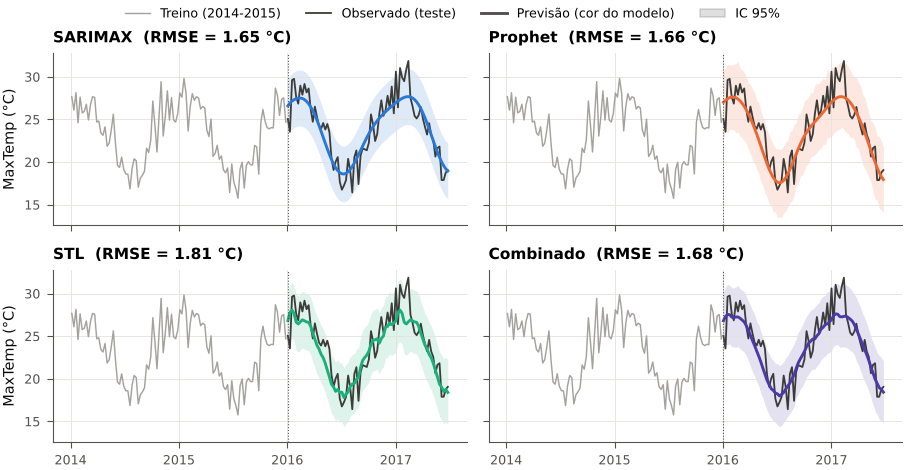

In [22]:
reg.plot_forecasts(train_full, test, fc_long)

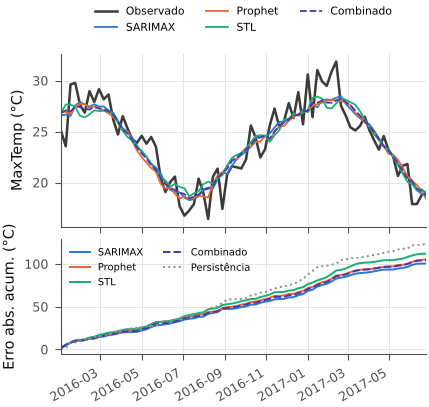

In [23]:
reg.plot_one_step(test, fc_one)

**Leitura:**
* O **SARIMAX vence nos dois cenários** (RMSE ≈ 1,65 °C no longo prazo e ≈ 1,59 °C um passo à frente), seguido de perto
  pelo Prophet e pelo Combinado. Todos superam o ingênuo; o melhor reduz o RMSE em ≈ 22%.
* No longo prazo, os três modelos convergem para a "climatologia" (ciclo anual médio + nível); as diferenças vêm de
  **como cada um estima o ciclo**: os harmônicos (SARIMAX/Prophet) dão um ciclo suave, enquanto o perfil STL,
  estimado semana a semana, ainda carrega ruído.
* No cenário um passo à frente, os erros ARMA do SARIMAX e o ARIMA(0,1,1) do STL incorporam a última observação;
  o Prophet, sem estado dinâmico, precisa ser re-treinado toda semana e ganha pouco.
* A **combinação não superou o melhor modelo**: os erros dos três são muito correlacionados (todos erram juntos nas
  ondas de calor do verão 2016/17) e o STL, mais fraco, puxa a média. Ainda assim é a segunda opção mais estável.
* As coberturas dos IC 95% ficam entre 92% e 97% — intervalos bem calibrados.

## 3.8 As diferenças são significativas? Teste de Diebold–Mariano
$d_t = e_{1,t}^2 - e_{2,t}^2$, $DM = \bar d / \sqrt{\widehat{\mathrm{Var}}(\bar d)}$ com correção de Harvey et al. (1997);
$H_0$: mesma acurácia. DM < 0 indica que o SARIMAX (modelo 1) erra menos.

In [24]:
reg.dm_table(test, fc_one, ref="SARIMAX")

,DM,p-valor
Prophet,-1.298,0.198
STL,-2.140,0.036
Combinado,-1.410,0.163
Persistência,-2.453,0.016


Com só 78 semanas de teste, o SARIMAX é **significativamente melhor que a persistência e que o STL**, mas
**não** se distingue estatisticamente do Prophet e do Combinado — honestamente, os três formam um empate técnico.

## 3.9 Robustez: backtest com origem móvel ($h = 52$)

In [ ]:
bt_wide, bt_long = reg.backtest(best, train_full)
bt_wide

Cada coluna é um ano previsto inteiramente fora da amostra (2012 a 2015; o teste não é usado). As médias ficam
entre 1,65 e 1,79 °C para os quatro modelos, contra 2,45 °C do ingênuo. O ranking varia de ano para ano
(o Prophet tem a menor média; o Combinado fica em segundo, com desvio menor que o SARIMAX) — outro sinal de que
os modelos são equivalentes no longo prazo e de que nenhuma vitória isolada deve ser superinterpretada.

## 3.10 Análise de resíduos (validação das premissas)
Para o SARIMAX, as premissas são: resíduos com **média zero**, **não autocorrelacionados** (Ljung–Box),
**homocedásticos** (ARCH-LM) e, para os intervalos, **normais** (Jarque–Bera, Shapiro–Wilk). Resíduos dentro da
amostra (treino + validação, descartando o 1º ano de *burn-in*).

Melhor modelo: SARIMAX


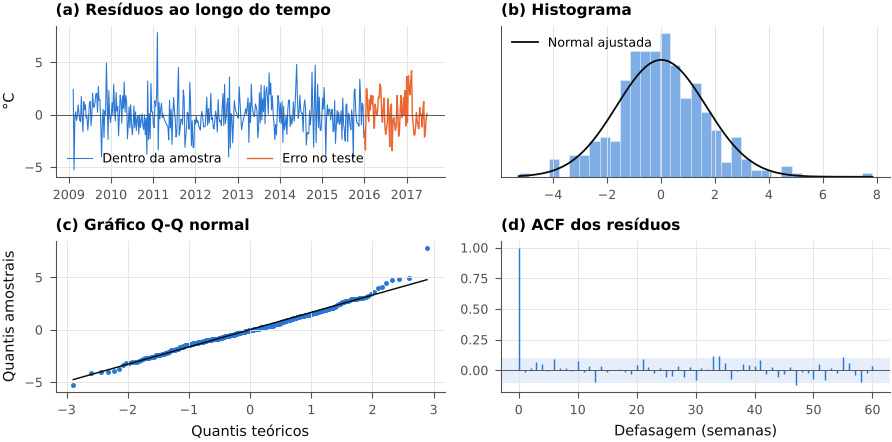

,Média,p t (média=0),p Ljung-Box(10),p Ljung-Box(52),p Jarque-Bera,p Shapiro-Wilk,p ARCH-LM(10)
SARIMAX,0.013,0.886,0.595,0.260,0.000,0.001,0.747
Prophet,-0.027,0.761,0.000,0.000,0.000,0.002,0.925
STL,0.023,0.797,0.600,0.052,0.000,0.000,0.942
Combinado,0.003,0.976,0.596,0.162,0.000,0.000,0.942


In [26]:
best_name = tab_long.loc[reg.MODEL_NAMES, "RMSE"].idxmin()
print("Melhor modelo:", best_name)
reg.residual_analysis(models, train_full, test, fc_long, best_name)

**Leitura (SARIMAX):**
* média ≈ 0 (p = 0,89) ✔ — sem viés;
* **Ljung–Box** com 10 e 52 defasagens: p = 0,60 e 0,26 ✔ — a ACF (d) fica dentro das bandas: os resíduos são ruído branco,
  a dinâmica foi capturada;
* **ARCH-LM** p = 0,75 ✔ — variância constante;
* **normalidade rejeitada** (JB e SW p < 0,01) ✘ — o Q-Q (c) mostra que o centro é normal e o desvio vem de poucos pontos
  na **cauda direita** (semanas de calor extremo, ex.: fev/2011). Com n ≈ 410 os testes detectam desvios pequenos;
  o impacto prático é limitado (a cobertura do IC 95% no teste foi 93,6%), mas intervalos *bootstrap* ou erros t-Student
  seriam um refinamento.
* O **Prophet** tem resíduos autocorrelacionados (Ljung–Box p ≈ 0): ele modela só tendência + sazonalidade
  e deixa a persistência de curto prazo no erro — limitação estrutural do modelo.

---
# 4. Classificação — vai chover amanhã?

### Definição
* **Alvo:** `RainTomorrow` ∈ {0, 1} (1 = mais de 1 mm de chuva no dia seguinte). Binário, 22% positivos.
* **Unidade:** um par (estação, dia); entradas = medições até o dia $t$; saída = chuva em $t+1$.

### Modelos escolhidos (justificativa)
| Modelo | Família | Por que incluir |
|---|---|---|
| Regressão Logística | GLM (binomial, link logit) | baseline linear, interpretável (odds ratios); exigência de GLM do enunciado |
| KNN | não paramétrico, baseado em distância | fronteira local e flexível, sem suposição de forma funcional |
| Random Forest | *bagging* de árvores | captura interações e não linearidades; robusto a outliers e escala |
| LightGBM | *gradient boosting* de árvores | estado da arte para dados tabulares; lida bem com desbalanceamento |

### Protocolo
* **Holdout temporal:** treino até 2015-12, teste 2016-01 a 2017-06 (evita "prever o passado com o futuro").
* Pré-processamento **dentro do `Pipeline`** → reajustado em cada dobra (sem vazamento).
* Hiperparâmetros: busca em grade/aleatória, 3 dobras estratificadas, ROC-AUC
  (amostra estratificada de 40 mil linhas para KNN, RF e LightGBM, por custo computacional).
* Robustez: **validação cruzada estratificada de 5 dobras** no treino completo.
* Limiar de decisão: maximiza o F1 nas previsões **fora-da-dobra** do treino; só depois é aplicado ao teste.

## 4.1 Engenharia de atributos
Todas as variáveis abaixo usam só informação disponível até o dia $t$ (podem ser criadas antes da divisão sem vazamento):

| Grupo | Variáveis | Motivação |
|---|---|---|
| Transformações | `log_Rainfall`, `log_Evaporation` | comprimir caudas muito assimétricas |
| Binárias | `RainToday`, `RainYesterday` | persistência da chuva |
| Variação intradiária | `TempRange`, `dTemp_9a15`, `dPressure_9a15`, `dHumidity_9a15`, `dCloud_9a15` | a **dinâmica** do dia (queda de pressão, aumento de umidade) |
| Variação de 24 h | `dPressure_24h`, `dHumidity_24h`, `dTemp_24h` | **tendência barométrica**, preditor clássico de frentes |
| Direção do vento | `WindGustDir_sin/cos`, ... | variável **circular**: N e NNW são vizinhos; one-hot ou ordinal perderiam isso |
| Sazonalidade | `doy_sin`, `doy_cos` | codificação cíclica do dia do ano (31/dez ≈ 1/jan) |
| Ausência | `miss_Sunshine`, `miss_Evaporation`, ... | ausência estrutural é informativa |
| Estação | `Location` → *target encoding* | 49 categorias; vira 1 coluna com a taxa de chuva da estação (estimada com *cross-fitting* para não vazar o alvo) |

Depois: imputação pela mediana + padronização (z-score) das numéricas.

In [27]:
Xtr, Xte, ytr, yte, info_clf = clf.prepare(df)
print(info_clf)
Xtr.head()

{'n_total': 142193, 'n_removidas_alvo': 3267, 'n_treino': 116219, 'n_teste': 25974, 'n_features': 41, 'pos_treino': 0.2231218647553326, 'pos_teste': 0.22892122892122893}


,MinTemp,MaxTemp,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,log_Rainfall,log_Evaporation,RainToday,TempRange,dTemp_9a15,dPressure_9a15,dHumidity_9a15,dCloud_9a15,dPressure_24h,dHumidity_24h,dTemp_24h,RainYesterday,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,doy_sin,doy_cos,miss_Sunshine,miss_Evaporation,miss_Cloud9am,miss_Cloud3pm,miss_Pressure3pm,miss_WindGustSpeed,Location
0,8.800,15.700,2.600,48.000,13.000,15.000,92.000,67.000,"1,017.400","1,017.700",NaN,NaN,13.500,14.900,1.792,0.956,1.000,6.900,1.400,0.300,-25.000,NaN,NaN,NaN,NaN,NaN,-0.707,0.707,-0.707,-0.707,-1.000,-0.000,-0.006,-1.000,0.000,0.000,1.000,1.000,0.000,0.000,Adelaide
1,12.700,15.800,7.800,35.000,13.000,15.000,75.000,52.000,"1,022.400","1,022.600",NaN,NaN,13.700,15.500,0.588,0.875,0.000,3.100,1.800,0.200,-23.000,NaN,4.900,-15.000,0.600,1.000,-0.707,-0.707,-0.383,-0.924,-0.707,-0.707,-0.024,-1.000,0.000,0.000,1.000,1.000,0.000,0.000,Adelaide
2,6.200,15.100,2.100,20.000,2.000,11.000,81.000,56.000,"1,027.800","1,026.500",NaN,NaN,9.300,13.900,0.000,1.030,0.000,8.900,4.600,-1.300,-25.000,NaN,3.900,4.000,-1.600,0.000,-1.000,-0.000,0.383,0.924,-0.707,-0.707,-0.041,-0.999,0.000,0.000,1.000,1.000,0.000,0.000,Adelaide
3,5.300,15.900,8.000,30.000,6.000,13.000,71.000,46.000,"1,028.700","1,025.600",NaN,NaN,10.200,15.300,0.000,0.875,0.000,10.600,5.100,-3.100,-25.000,NaN,-0.900,-10.000,1.400,0.000,0.383,0.924,0.383,0.924,0.707,0.707,-0.058,-0.998,0.000,0.000,1.000,1.000,0.000,0.000,Adelaide
5,11.300,15.700,1.500,52.000,15.000,22.000,62.000,62.000,"1,019.500","1,016.200",NaN,NaN,13.000,14.400,NaN,NaN,NaN,4.400,1.400,-3.300,0.000,NaN,-4.000,-5.000,0.600,0.000,-0.383,0.924,0.383,0.924,-0.383,0.924,-0.092,-0.996,0.000,1.000,1.000,1.000,0.000,0.000,Adelaide


In [28]:
pre = clf.make_preprocessor(Xtr)
pre

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('loc', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer

## 4.2 Formulação dos modelos
* **Regressão logística (GLM):** $\;\Pr(Y=1\mid\mathbf x) = \sigma(\beta_0 + \boldsymbol\beta^\top\mathbf x)$, $\sigma(z) = 1/(1+e^{-z})$.
  Estimada minimizando a log-verossimilhança negativa ponderada + penalidade L2:
  $\;\min_{\boldsymbol\beta}\ -\sum_i w_{y_i}\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big] + \tfrac{1}{2C}\lVert\boldsymbol\beta\rVert^2$,
  com pesos $w_c = n/(2 n_c)$ ("balanced") para compensar o desbalanceamento. $e^{\beta_j}$ é a razão de chances por 1 desvio-padrão.
* **KNN:** $\;\hat p(\mathbf x) = \sum_{i \in N_k(\mathbf x)} w_i y_i / \sum w_i$, com $w_i = 1/d(\mathbf x, \mathbf x_i)$ (pesos por distância euclidiana).
* **Random Forest:** $\;\hat p(\mathbf x) = \frac1B\sum_{b=1}^{B} T_b(\mathbf x)$; cada árvore é treinada numa amostra *bootstrap* e
  em cada nó sorteia um subconjunto das variáveis (descorrelaciona as árvores e reduz variância).
* **LightGBM:** modelo aditivo $F_M(\mathbf x) = \sum_{m=1}^{M} \eta\, f_m(\mathbf x)$, em que cada árvore $f_m$ ajusta o gradiente
  (e a hessiana) da perda logística das iterações anteriores; crescimento *leaf-wise*, histogramas e regularização L2.

## 4.3 Ajuste de hiperparâmetros

In [29]:
best_clf, tab_hp_clf = clf.tune(Xtr, ytr)
tab_hp_clf

[Regressão Logística] {'C': 0.1}  AUC=0.8730  (16s)


[KNN] {'n_neighbors': 61, 'weights': 'distance'}  AUC=0.8754  (40s)


[Random Forest] {'min_samples_leaf': 1, 'max_features': 0.4, 'max_depth': None}  AUC=0.8873  (339s)


[LightGBM] {'reg_lambda': 1.0, 'num_leaves': 127, 'n_estimators': 1000, 'min_child_samples': 50, 'learning_rate': 0.02, 'colsample_bytree': 0.6}  AUC=0.8972  (151s)


,Melhores hiperparâmetros,AUC (busca),Amostra
Modelo,,,
Regressão Logística,C=0.1,0.873,116 mil
KNN,"k=61, pesos=distance",0.875,40 mil
Random Forest,"min_folha=1, max_feat=0.4, prof.=None",0.887,40 mil
LightGBM,"lambda=1.0, folhas=127, árvores=1000, min_filh...",0.897,40 mil


## 4.4 Validação cruzada estratificada (5 dobras, treino completo)

[CV] Regressão Logística: 6s


[CV] KNN: 31s


[CV] Random Forest: 414s


[CV] LightGBM: 73s


,ROC-AUC,PR-AUC,F1,Revocação,Precisão,Acurácia bal.
Regressão Logística,0.873 ± 0.003,0.702 ± 0.006,0.628 ± 0.004,0.774 ± 0.009,0.528 ± 0.004,0.788 ± 0.004
KNN,0.884 ± 0.002,0.728 ± 0.003,0.579 ± 0.003,0.456 ± 0.005,0.796 ± 0.004,0.711 ± 0.002
Random Forest,0.898 ± 0.002,0.748 ± 0.005,0.614 ± 0.003,0.503 ± 0.005,0.788 ± 0.007,0.732 ± 0.002
LightGBM,0.908 ± 0.002,0.776 ± 0.005,0.690 ± 0.005,0.767 ± 0.004,0.627 ± 0.009,0.818 ± 0.002


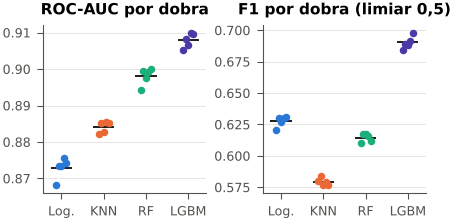

In [30]:
tab_cv, cv_long, oof = clf.cross_validate_models(best_clf, Xtr, ytr)
display(tab_cv)
clf.plot_cv(cv_long)

**Leitura:** a variação entre dobras é pequena (desvio ≤ 0,003 em AUC) → as estimativas são **robustas** e o ranking
**LightGBM > Random Forest > KNN > Logística** é consistente em todas as dobras. Com limiar 0,5, KNN e Random Forest têm
revocação baixa (≈ 0,46 e 0,50): o KNN não usa pesos de classe e a RF, mesmo com pesos, concentra as probabilidades
da classe minoritária abaixo de 0,5 — o ajuste de limiar a seguir (≈ 0,28 e 0,32) corrige isso.

## 4.5 Limiar de decisão (escolhido fora-da-dobra)

In [31]:
thr = clf.best_thresholds(ytr, oof)
pd.Series(thr, name="limiar que maximiza F1")

Regressão Logística   0.604
KNN                   0.282
Random Forest         0.317
LightGBM              0.571
Name: limiar que maximiza F1, dtype: float64

## 4.6 Avaliação no teste temporal (2016–2017)

In [32]:
tab_test, fitted, probs = clf.evaluate_test(best_clf, thr, Xtr, ytr, Xte, yte)
tab_test

[Teste] Regressão Logística: AUC=0.8621 F1=0.6351 (6s)


[Teste] KNN: AUC=0.8669 F1=0.6423 (12s)


[Teste] Random Forest: AUC=0.8796 F1=0.6619 (111s)


[Teste] LightGBM: AUC=0.8888 F1=0.6737 (21s)


,Limiar,Acurácia,Acurácia bal.,Precisão,Revocação,F1,ROC-AUC,PR-AUC,Brier,AUC IC95 inf,AUC IC95 sup
Regressão Logística,0.604,0.824,0.769,0.606,0.668,0.635,0.862,0.691,0.147,0.856,0.867
KNN,0.282,0.825,0.776,0.603,0.688,0.642,0.867,0.711,0.113,0.862,0.872
Random Forest,0.317,0.837,0.788,0.630,0.697,0.662,0.880,0.725,0.108,0.875,0.884
LightGBM,0.571,0.843,0.795,0.643,0.708,0.674,0.889,0.752,0.122,0.884,0.893


**Leitura:** o **LightGBM vence em todas as métricas de discriminação** (ROC-AUC 0,889 [IC 95% bootstrap 0,884–0,893],
PR-AUC 0,752, F1 0,674). Os IC de AUC do LightGBM e da Random Forest não se sobrepõem aos da logística/KNN.
As AUC de teste são ~0,01–0,02 menores que as da validação cruzada: o teste está **no futuro**, e a CV com dobras
aleatórias mistura dias vizinhos (e o mesmo dia em estações próximas) entre treino e validação — fica levemente otimista.

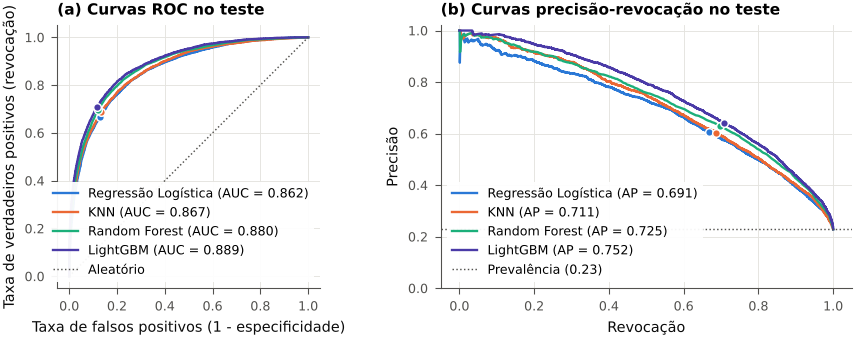

In [33]:
clf.plot_roc_pr(yte, probs, thr)

Os pontos marcam o limiar escolhido. A curva **precisão–revocação** é mais informativa que a ROC sob desbalanceamento
(Saito & Rehmsmeier, 2015): a linha de base é a prevalência (0,23), e o ganho do LightGBM fica mais visível.

## 4.7 Matriz de confusão do melhor modelo

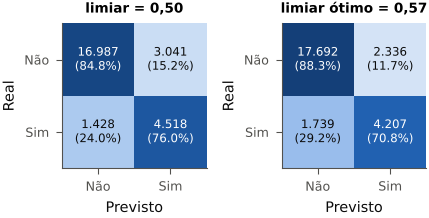

,"limiar = 0,50","limiar ótimo = 0,57"
VN,16987,17692
FP,3041,2336
FN,1428,1739
VP,4518,4207


In [34]:
best_clf_name = tab_test["ROC-AUC"].astype(float).idxmax()
cm = clf.plot_confusion(yte, probs[best_clf_name], thr[best_clf_name], best_clf_name)
cm

**Leitura (LightGBM, limiar ótimo):** de 5.946 dias com chuva, acerta 4.207 (**revocação 70,8%**) e, quando diz "vai chover",
acerta 64% das vezes (**precisão**). Entre os 20.028 dias secos, 88,3% são corretamente classificados.
O limiar é uma **decisão de negócio**: com 0,50, a revocação sobe para 76% ao custo de 705 alarmes falsos a mais.
Para alerta de chuva forte (custo alto de FN) usaríamos limiar menor; para um app de consumo (custo de "alarme falso"), maior.

## 4.8 Interpretação: importância das variáveis

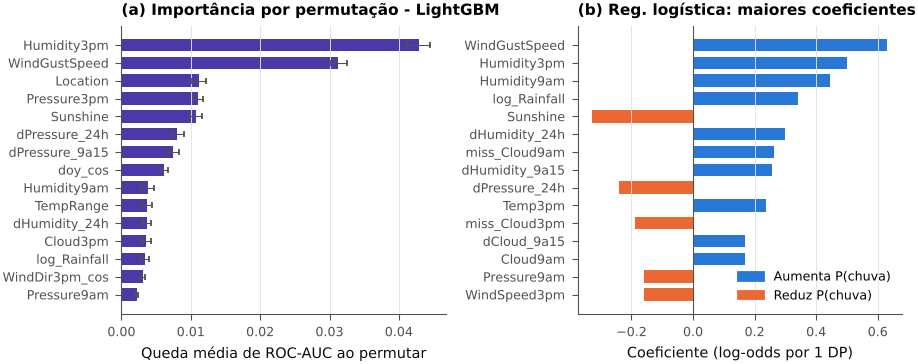

,media,dp
Humidity3pm,0.043,0.002
WindGustSpeed,0.031,0.001
Location,0.011,0.001
Pressure3pm,0.011,0.001
Sunshine,0.011,0.001
dPressure_24h,0.008,0.001
dPressure_9a15,0.007,0.001
doy_cos,0.006,0.001
Humidity9am,0.004,0.001
TempRange,0.004,0.001


In [35]:
imp = clf.plot_importance(fitted, Xte, yte, best_clf_name)
imp.head(12)

**Leitura:** `Humidity3pm` e `WindGustSpeed` dominam nos dois modelos — fisicamente: ar úmido à tarde e rajadas fortes
indicam a aproximação de sistemas frontais. Aparecem em seguida pressão, insolação, a **tendência barométrica**
`dPressure_24h` (queda de pressão → chuva; coeficiente negativo na logística) e `dPressure_9a15` — atributos de
engenharia que capturam a **dinâmica** do sistema. A estação (`Location`) e a sazonalidade (`doy_cos`) também contam.

## 4.9 Calibração das probabilidades

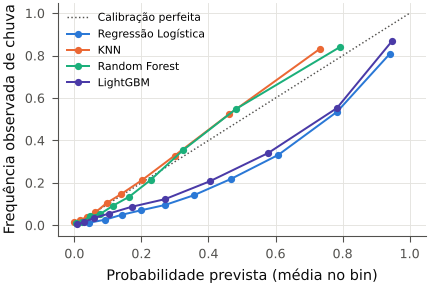

In [36]:
clf.plot_calibration(yte, probs)

Os modelos com `class_weight='balanced'` (logística e LightGBM) **superestimam** a probabilidade de chuva — efeito
esperado da reponderação, que desloca $\Pr(Y=1)$ para cima. Isso não afeta a ordenação (AUC) nem o F1 com limiar ajustado,
mas, se probabilidades calibradas forem necessárias (ex.: "60% de chance de chuva"), devemos aplicar calibração de Platt
ou isotônica sobre o LightGBM.

---
# 5. Conclusões

**Regressão.** Os quatro modelos supervisionados preveem a temperatura máxima semanal de Sydney com erro de ≈ 1,6–1,8 °C,
14–22% abaixo do ingênuo. O **SARIMAX com harmônicos de Fourier e erros ARMA(1,1)** teve o menor erro nos dois cenários de
teste e os resíduos mais bem-comportados (ruído branco, homocedásticos), mas não é estatisticamente distinguível do Prophet
e da combinação. A média simples não superou o melhor modelo porque os erros dos componentes são muito correlacionados.

**Classificação.** O **LightGBM** foi o melhor classificador (ROC-AUC 0,889, F1 0,674 no teste futuro), seguido da Random
Forest; as variáveis de umidade, rajada e a dinâmica da pressão foram as mais informativas.

**Limitações e próximos passos.** (i) uma única estação na regressão — um modelo hierárquico com várias estações e
covariáveis climáticas (ENSO/SOI) poderia melhorar o longo prazo; (ii) cauda direita dos resíduos não normal → IC por
*bootstrap*; (iii) CV com dobras aleatórias é levemente otimista → usar validação por blocos temporais; (iv) calibrar as
probabilidades antes de uso operacional; (v) os dados terminam em 2017 — antes de produção seria preciso re-treinar com
dados recentes e monitorar *drift* climático.